# 라이브러리 및 데이터 호출

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
from google.colab import files
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.8f}'.format
pd.set_option('display.max_columns', 100)

In [5]:
train = pd.read_parquet('/content/drive/MyDrive/EPOCH_5th_Miniproject/Real/train.parquet')
train.head()

,ID,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.46819090,0.53663323,0.51999572,0.60958647,0.60958647,0.99910532,0.79746029,0.80937572,0.30336283,0.78165012,0.00011992,0.00000000,0.46159718,0.00032603,0.08745824,0.19657832,0.19657832,0.19657832,0.21934386,0.31933932,0.01293162,0.10390033,0.17375913,0.02206852,0.84801188,0.68934674,0.68934674,0.21759205,6770000000.00000000,0.00049784,0.26397495,0.37722141,0.00703648,0.00017904,0.63624437,0.02144101,0.20809021,0.79190979,0.00552301,0.38982359,0.00676245,0.10380738,0.17264158,0.42655438,0.02248876,0.00387733,0.00163097,32500000.00000000,9910000000.00000000,0.01774194,0.14133925,0.46009814,0.18340296,0.78293591,0.05848713,0.78410095,0.01407253,0.00042065,0.00036239,0.20603382,0.34125466,0.28005080,0.01743145,0.94919197,0.73638428,0.34431216,0.00136410,0.93669589,0.00231377,0.00519167,0.00145259,0.00011279,0.59406567,6770000000.00000000,0.67158878,0.11764985,0.94919197,0.34431216,0.11428337,0.64735874,0.45982148,0.56863670,0.31594354,0.04109148,0,0.79849329,0.02070590,0.61782973,0.60958733,0.84043400,0.29032832,0.02721922,0.56661105,1,0.01641835
1,1,0,0.54648272,0.62036633,0.59799775,0.61187103,0.61199354,0.99918551,0.79794504,0.80978871,0.30404200,0.78203019,7830000000.00000000,747000000.00000000,0.48724659,0.00038204,0.09484766,0.19855885,0.19855885,0.19855885,0.24212915,0.32888873,0.01335511,0.1091930

In [6]:
test = pd.read_parquet('/content/drive/MyDrive/EPOCH_5th_Miniproject/Real/test.parquet')
test.head()

,ID,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,4773,0.51464925,0.58008068,0.57042668,0.60150766,0.60151487,0.99907019,0.79751272,0.80942767,0.30352815,0.78169671,2560000000.00000000,560000000.00000000,0.46939433,0.00000000,0.03269562,0.19560912,0.19560912,0.19560912,0.23380921,0.32903020,0.03280548,0.11196157,0.18543346,0.02226853,0.84823164,0.68971832,0.68971832,0.21763634,7640000000.00000000,0.00046612,0.26443496,0.39310197,0.01124053,0.01051358,0.63061225,0.00378355,0.08643468,0.91356532,0.00636132,0.36963718,0.00536585,0.11168108,0.18439786,0.39949734,0.14542729,0.00078520,0.00805492,0.00045896,0.00059082,0.03064516,0.24471013,0.48133240,0.05442587,0.81801366,0.52036194,0.52982108,0.22613141,0.01070504,0.01349560,0.08863103,0.36370477,0.27703844,0.00173676,0.95804962,0.73586299,0.32948836,0.00000000,0.94354432,0.00307739,0.00544946,0.00014934,0.00015244,0.59396642,0.00017972,0.67162511,0.12211131,0.95804962,0.32948836,0.11093323,0.72890293,0.48410730,0.63040487,0.32592026,0.02601816,0,0.82300846,0.00904185,0.64604282,0.60150244,0.84181588,0.27752296,0.02679116,0.56515840,1,0.04429732
1,4774,0.55150392,0.61322503,0.59644521,0.60145721,0.60145721,0.99906153,0.79751175,0.80940996,0.30354483,0.78167482,3330000000.00000000,153000000.00000000,0.45896681,0.00017402,0.17157607,0.19948590,0.19948590,0.19948590,0.25753995,0.31078022,0.08769303,0.13647097,0.21156888,0.0

### 1회 제출 코드 (모든 test를 파산 1으로 예측)

In [ ]:
X_train = train.drop(columns=['Bankrupt?', 'ID'])
y_train = train['Bankrupt?']

# 테스트 데이터에서 ID 따로 보관하기
test_id = test['ID'].copy()

# 예측을 위해 test에서 ID 컬럼 제거
X_test = test.drop(columns=['ID'])

submission = pd.DataFrame({
    'ID': test['ID'],
    'Bankrupt?': 1
})

print(submission['Bankrupt?'].value_counts())

Bankrupt?
1    2046
Name: count, dtype: int64


In [ ]:
submission.to_csv('result.csv', index=False, encoding='utf-8')
files.download('result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1.EDA

In [7]:
train.describe()

,ID,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.00000000,4773.000

In [8]:
train['Bankrupt?'].value_counts()

,count
Bankrupt?,
0,4619
1,154


In [9]:
# 각 컬럼의 최소값과 최대값 확인
stats = train.describe().T[['min', 'max']]

# 최소값이 0보다 작거나, 최대값이 1보다 큰 컬럼만 필터링
out_of_range = stats[(stats['min'] < -0.00001) | (stats['max'] > 1.00001)]

print(f"0~1 범위를 벗어나는 변수 개수: {len(out_of_range)}개")
print(out_of_range)

0~1 범위를 벗어나는 변수 개수: 25개
                                              min                  max
ID                                     0.00000000        4772.00000000
 Operating Expense Rate                0.00000000  9980000000.00000000
 Research and development expense rate 0.00000000  9980000000.00000000
 Interest-bearing debt interest rate   0.00000000   990000000.00000000
 Revenue Per Share (Yuan ¥)            0.00000000  1510000000.00000000
 Total Asset Growth Rate               0.00010000  9980000000.00000000
 Net Value Growth Rate                 0.00000000  9330000000.00000000
 Current Ratio                         0.00000000  2750000000.00000000
 Quick Ratio                           0.00000000  9230000000.00000000
 Total debt/Total net worth            0.00012949  6470000000.00000000
 Accounts Receivable Turnover          0.00000000  9740000000.00000000
 Average Collection Days               0.00000000  9730000000.00000000
 Inventory Turnover Rate (times)       0.00000000  99

## 다중공선성 찾기

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 수치형 데이터만 선택 (이미 정규화 되어 있다면 그대로 사용)
features = train.drop(columns=['Bankrupt?'])

# VIF 계산을 위한 데이터 프레임 생성
vif_data = pd.DataFrame()
vif_data["feature"] = features.columns

# 각 변수별 VIF 값 계산
vif_data["VIF"] = [variance_inflation_factor(features.values, i)
                   for i in range(len(features.columns))]

# VIF가 높은 순서대로 정렬하여 확인
print(vif_data.sort_values(by="VIF", ascending=False).head(50))

                                              feature                   VIF
77                     Current Liability to Liability 172710524136.00613403
64                      Current Liabilities/Liability  73459794597.19927979
56                        Current Assets/Total Assets  44841161427.30332947
54                    Working Capital to Total Assets  14234352364.31833458
38                                   Net worth/Assets   7463463854.53319931
60                        Current Liability to Assets   4238887463.59987879
66                         Current Liabilities/Equity    351794730.72367042
78                        Current Liability to Equity    316448065.32637143
37                                       Debt ratio %    230320699.06554544
6                               Operating Profit Rate    184001882.64757615
7                           Pre-tax net Interest Rate     67842901.54109038
4                              Operating Gross Margin     47145380.54761188
89          

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def reduce_vif(df, threshold=50):
    X = df.drop(columns=['ID', 'Bankrupt?']) if 'Bankrupt?' in df.columns else df.drop(columns=['ID'])

    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

        max_vif = vif_data["VIF"].max()
        if max_vif <= threshold:
            break

        feature_to_drop = vif_data.sort_values("VIF", ascending=False).iloc[0]["feature"]
        print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
        X = X.drop(columns=[feature_to_drop])

    return X.columns.tolist()

final_features = reduce_vif(train, threshold=20)
print(f"\n최종 선택된 피처 개수: {len(final_features)}개")
print(final_features)

Dropping ' Current Liabilities/Liability' (VIF: 156223103488.64)
Dropping ' Net worth/Assets' (VIF: 14841983833.09)
Dropping ' Net Income Flag' (VIF: 652553738661.23)
Dropping ' Operating Profit Rate' (VIF: 1992743197951.55)
Dropping ' Operating Gross Margin' (VIF: 60094869029.45)
Dropping ' Current Liabilities/Equity' (VIF: 1925540966.22)
Dropping ' Working Capital to Total Assets' (VIF: 6499.77)
Dropping ' Net Value Per Share (A)' (VIF: 5309.73)
Dropping ' Continuous interest rate (after tax)' (VIF: 3194.28)
Dropping ' After-tax net Interest Rate' (VIF: 1251.43)
Dropping ' Gross Profit to Sales' (VIF: 1142.55)
Dropping ' Net Value Per Share (C)' (VIF: 1130.75)
Dropping ' Operating Profit Per Share (Yuan ¥)' (VIF: 710.47)
Dropping ' Liability to Equity' (VIF: 680.30)
Dropping ' ROA(B) before interest and depreciation after tax' (VIF: 96.90)
Dropping ' Current Liability to Equity' (VIF: 86.29)
Dropping ' Retained Earnings to Total Assets' (VIF: 5899.50)
Dropping ' After-tax Net Profit 

In [27]:
drop_features = train[final_features]

# VIF 계산을 위한 데이터 프레임 생성
vif_data = pd.DataFrame()
vif_data["feature"] = drop_features.columns

# 각 변수별 VIF 값 계산
vif_data["VIF"] = [variance_inflation_factor(drop_features.values, i)
                   for i in range(len(drop_features.columns))]

# VIF가 높은 순서대로 정렬하여 확인
print(vif_data.sort_values(by="VIF", ascending=False))

                                      feature         VIF
26      Net profit before tax/Paid-in capital 17.32584542
9     Persistent EPS in the Last Four Seasons 16.76156066
23                       Borrowing dependency 15.69597030
12   Per Share Net profit before tax (Yuan ¥) 14.70584091
44                     Working Capital/Equity 12.50265232
..                                        ...         ...
18                                Quick Ratio  1.03993656
45      Long-term Liability to Current Assets  1.03449442
40                     Cash/Current Liability  1.03350914
62         Degree of Financial Leverage (DFL)  1.00484270
19                     Interest Expense Ratio  0.95317285

[64 rows x 2 columns]


In [14]:
train[final_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4773 entries, 0 to 4772
Data columns (total 64 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  4773 non-null   float64
 1    Realized Sales Gross Margin                              4773 non-null   float64
 2    Pre-tax net Interest Rate                                4773 non-null   float64
 3    Non-industry income and expenditure/revenue              4773 non-null   float64
 4    Operating Expense Rate                                   4773 non-null   float64
 5    Research and development expense rate                    4773 non-null   float64
 6    Interest-bearing debt interest rate                      4773 non-null   float64
 7    Tax rate (A)                                             4773 non-null   float64
 8    Net Value Per Sha

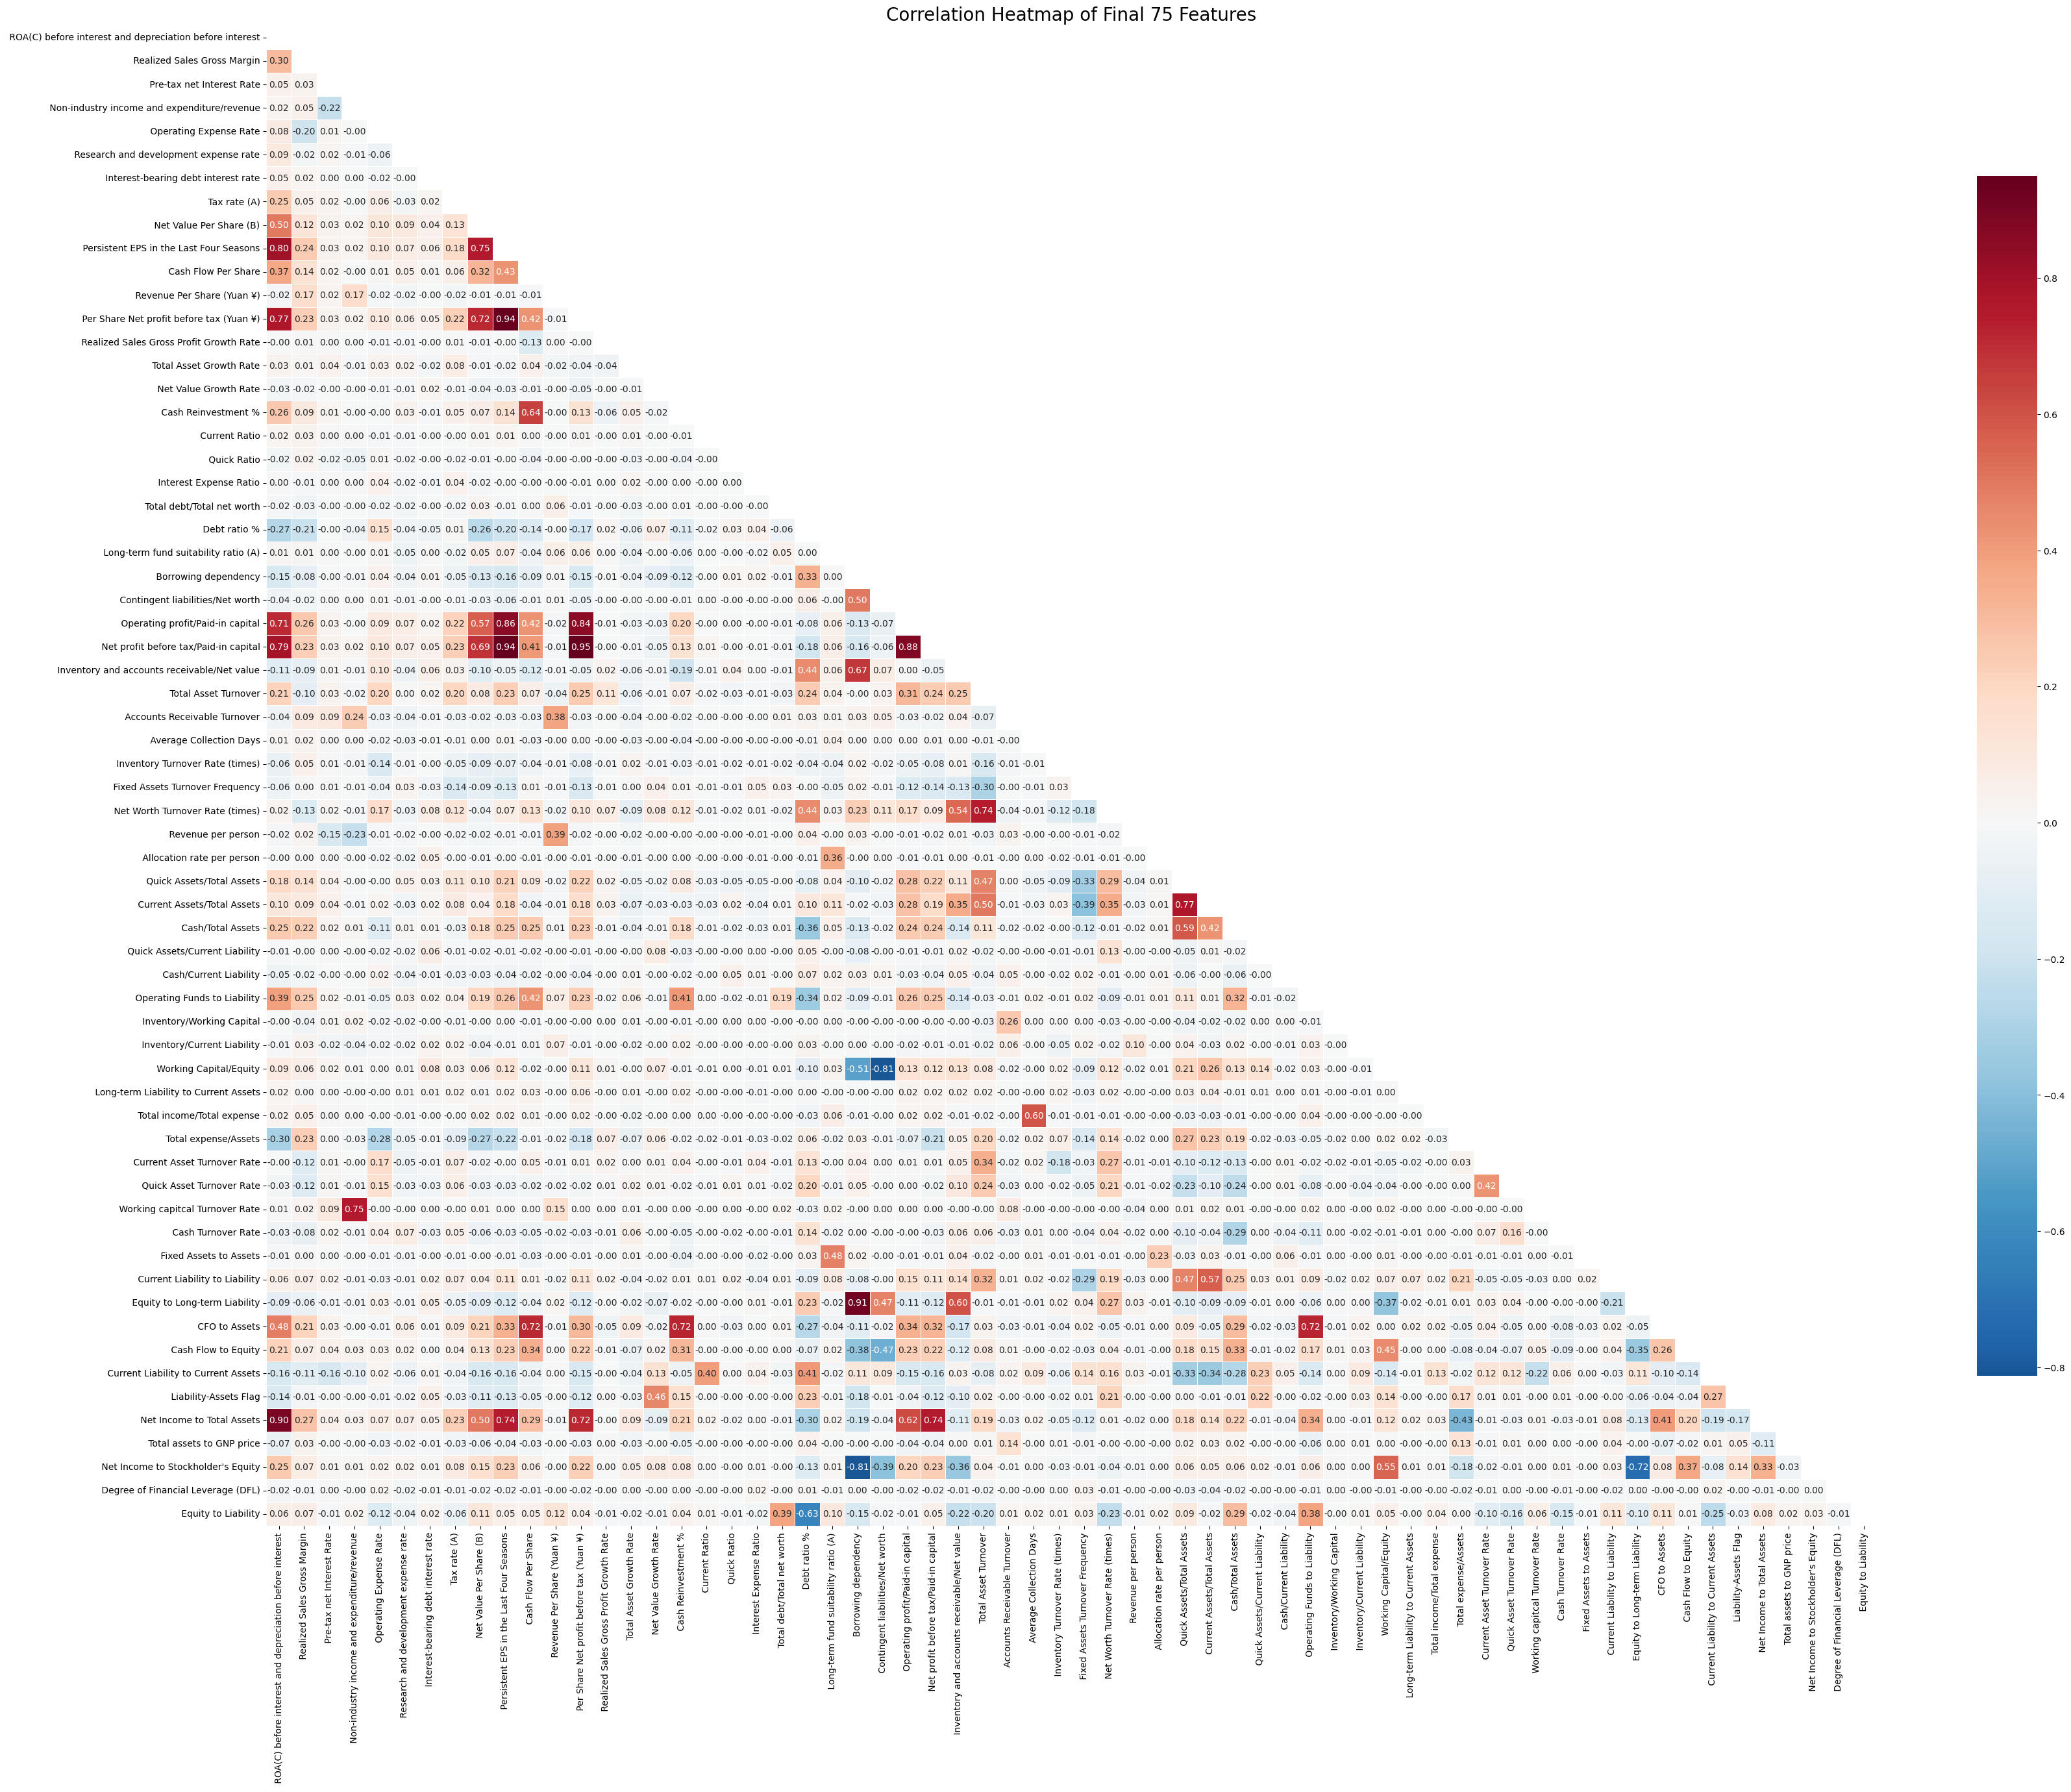

In [15]:
corr_64 = train[final_features].corr()

mask = np.triu(np.ones_like(corr_64, dtype=bool))

# 히트맵 그리기
plt.figure(figsize=(40, 30))

sns.heatmap(corr_64,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Final 75 Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

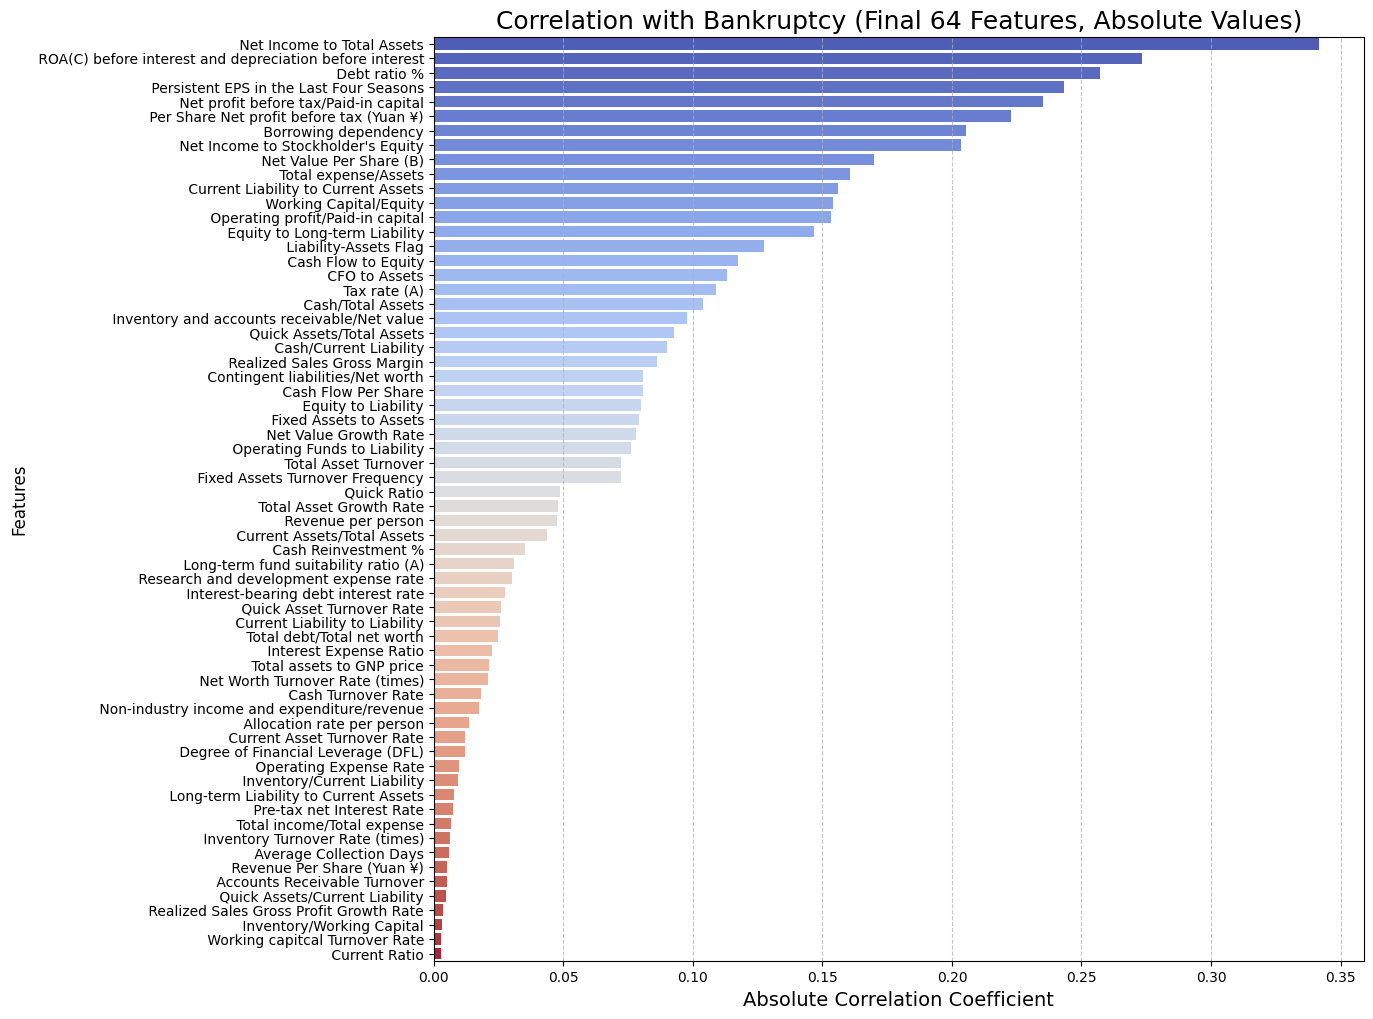

In [62]:
analysis_cols = fff + ['Bankrupt?']
X_final = train[analysis_cols]

target_corr = X_final.corr(numeric_only=True)['Bankrupt?']
target_corr_sorted = target_corr.drop('Bankrupt?').abs().sort_values(ascending=False)

# 시각화 (막대그래프)
plt.figure(figsize=(12, 12))

sns.barplot(x=target_corr_sorted.values,
            y=target_corr_sorted.index,
            palette='coolwarm')

plt.title('Correlation with Bankruptcy (Final 64 Features, Absolute Values)', fontsize=18)
plt.xlabel('Absolute Correlation Coefficient', fontsize=14)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # 그리드 추가로 가독성 향상
plt.show()

### 0과 1사이와 아닌 변수들

In [17]:
# 각 컬럼의 최소값과 최대값 확인
stats = train[final_features].describe().T[['min', 'max']]

# 최소값이 0보다 작거나, 최대값이 1보다 큰 컬럼만 필터링
out_of_range = stats[(stats['min'] < -0.00001) | (stats['max'] > 1.00001)]

print(f"0~1 범위를 벗어나는 변수 개수: {len(out_of_range)}개")
print(out_of_range)

0~1 범위를 벗어나는 변수 개수: 24개
                                             min                  max
Operating Expense Rate                0.00000000  9980000000.00000000
Research and development expense rate 0.00000000  9980000000.00000000
Interest-bearing debt interest rate   0.00000000   990000000.00000000
Revenue Per Share (Yuan ¥)            0.00000000  1510000000.00000000
Total Asset Growth Rate               0.00010000  9980000000.00000000
Net Value Growth Rate                 0.00000000  9330000000.00000000
Current Ratio                         0.00000000  2750000000.00000000
Quick Ratio                           0.00000000  9230000000.00000000
Total debt/Total net worth            0.00012949  6470000000.00000000
Accounts Receivable Turnover          0.00000000  9740000000.00000000
Average Collection Days               0.00000000  9730000000.00000000
Inventory Turnover Rate (times)       0.00000000  9990000000.00000000
Fixed Assets Turnover Frequency       0.00000000  9990000000.00000

In [18]:
out_of_range = out_of_range.index.tolist()
out_of_range

[' Operating Expense Rate',
 ' Research and development expense rate',
 ' Interest-bearing debt interest rate',
 ' Revenue Per Share (Yuan ¥)',
 ' Total Asset Growth Rate',
 ' Net Value Growth Rate',
 ' Current Ratio',
 ' Quick Ratio',
 ' Total debt/Total net worth',
 ' Accounts Receivable Turnover',
 ' Average Collection Days',
 ' Inventory Turnover Rate (times)',
 ' Fixed Assets Turnover Frequency',
 ' Revenue per person',
 ' Allocation rate per person',
 ' Quick Assets/Current Liability',
 ' Cash/Current Liability',
 ' Inventory/Current Liability',
 ' Long-term Liability to Current Assets',
 ' Current Asset Turnover Rate',
 ' Quick Asset Turnover Rate',
 ' Cash Turnover Rate',
 ' Fixed Assets to Assets',
 ' Total assets to GNP price']

# RF와 CV

In [ ]:
# 파생 변수 생성
def super_engineer(df):
    df_new = df.copy()

    # 'Debt ratio %'가 없으면 'Net worth/Assets'를 이용해서 역산 (1 - 자기자본비율)
    # 둘 다 없다면 가장 상관관계가 높았던 다른 부채 관련 지표를 사용
    if 'Debt ratio %' in df_new.columns:
        debt_col = df_new['Debt ratio %']
    elif 'Net worth/Assets' in df_new.columns:
        debt_col = 1 - df_new['Net worth/Assets'] # 비율이 0~1 사이일 경우
    else:
        # 둘 다 없다면 부채 관련 다른 변수 아무거나(예: Borrowing dependency) 사용
        debt_col = df_new.get('Borrowing dependency', 0)

    # 상환능력 지수
    cash_col = df_new.get('Cash Flow to Total Assets', 1e-9)
    df_new['Debt_No_Cash'] = debt_col / (cash_col + 1e-9)

    # 비효율적 좀비 기업 지표
    net_income = df_new.get('Net Income to Total Assets', 0)
    gnp_price = df_new.get('Total assets to GNP price', 1e-9)
    df_new['Big_Asset_Low_Profit'] = net_income / (gnp_price + 1e-9)

    # 자본 구조의 취약성 지표
    net_value = df_new.get('Net Value Per Share (A)', 0)
    borrow_dep = df_new.get('Borrowing dependency', 0)
    df_new['Equity_Weakness'] = net_value * borrow_dep

    return df_new


In [35]:
# 데이터 준비 및 상위 40개 피처 선정
X_eng = super_engineer(train[final_features])
X_test_eng = super_engineer(test[final_features])
y = train['Bankrupt?']

# 타겟과 상관관계가 높은 상위 40개만 선택 (파생변수 포함)
corr_matrix = X_eng.copy()
corr_matrix['target'] = y
top_40_features = corr_matrix.corr()['target'].abs().sort_values(ascending=False).drop('target').head(40).index.tolist()

X_final = X_eng[top_40_features]
X_test_final = X_test_eng[top_40_features]

# SMOTE (1의 비중을 조금 더 정교하게 조절)
smote = SMOTE(sampling_strategy=0.6, random_state=42) # 0.5에서 0.6으로 상향
X_res, y_res = smote.fit_resample(X_final, y)

# 각성한 Random Forest
rf_ace = RandomForestClassifier(
    n_estimators=700,      # 나무를 더 심어서 안정성 강화
    max_depth=15,          # 조금 더 깊게 파고들기 허용
    min_samples_leaf=2,    # 너무 일반화되지 않게 살짝 조임
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_ace.fit(X_res, y_res)

# 확률 예측 및 타겟 개수 추출
probs = rf_ace.predict_proba(X_test_final)[:, 1]

for count in [190, 200, 210]:
    threshold = np.sort(probs)[-count]
    preds = (probs >= threshold).astype(int)

    filename = f'result_RF_ACE_{count}.csv'
    pd.DataFrame({'ID': test['ID'], 'Bankrupt?': preds}).to_csv(filename, index=False)
    print(f"생성 완료: {filename} (1의 개수: {sum(preds)})")

생성 완료: result_RF_ACE_190.csv (1의 개수: 190)
생성 완료: result_RF_ACE_200.csv (1의 개수: 200)
생성 완료: result_RF_ACE_210.csv (1의 개수: 210)


In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_thresholds = []
cv_scores = []

for train_idx, val_idx in skf.split(X_eng, y):
    X_tr, X_val = X_eng.iloc[train_idx], X_eng.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    smote_fold = SMOTE(sampling_strategy=0.6, random_state=42)
    X_tr_res, y_tr_res = smote_fold.fit_resample(X_tr, y_tr)

    # 학습 및 예측
    rf_ace.fit(X_tr_res, y_tr_res)
    val_probs = rf_ace.predict_proba(X_val)[:, 1]

    # 최적 임계값 탐색
    best_f2 = 0
    best_t = 0.5
    for t in np.arange(0.1, 0.6, 0.01):
        score = fbeta_score(y_val, (val_probs > t).astype(int), beta=2)
        if score > best_f2:
            best_f2 = score
            best_t = t

    cv_thresholds.append(best_t)
    cv_scores.append(best_f2)
    print(f"Fold Score: {best_f2:.4f}")

print(f"\n진짜 평균 CV F2 점수: {np.mean(cv_scores):.4f}")
print(f"진짜 Private 방어용 임계값: {np.mean(cv_thresholds):.4f}")

Fold Score: 0.5455
Fold Score: 0.5924
Fold Score: 0.6220
Fold Score: 0.5180
Fold Score: 0.5580

진짜 평균 CV F2 점수: 0.5672
진짜 Private 방어용 임계값: 0.3200


In [44]:
# 5개 폴드 모델의 예측 확률을 저장할 리스트
all_test_probs = []

# 다시 5-Fold를 돌며 '앙상블'용 확률 수집
for i, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):
    X_tr, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # SMOTE 적용
    smote_fold = SMOTE(sampling_strategy=0.6, random_state=42)
    X_tr_res, y_tr_res = smote_fold.fit_resample(X_tr, y_tr)

    # 모델 학습
    rf_ace.fit(X_tr_res, y_tr_res)

    # 테스트 데이터에 대한 '확률' 예측값 저장
    test_prob = rf_ace.predict_proba(X_test_final)[:, 1]
    all_test_probs.append(test_prob)
    print(f"✅ 모델 {i+1}의 예측 확률 수집 완료")

# 5개 모델의 확률 평균 내기 (이게 핵심!)
avg_probs = np.mean(all_test_probs, axis=0)


✅ 모델 1의 예측 확률 수집 완료
✅ 모델 2의 예측 확률 수집 완료
✅ 모델 3의 예측 확률 수집 완료
✅ 모델 4의 예측 확률 수집 완료
✅ 모델 5의 예측 확률 수집 완료

파일 생성 완료! 0.32 임계값 기준 1의 개수: 186


In [56]:
final_preds_a = (avg_probs > 0.319).astype(int)
pd.DataFrame({'ID': test['ID'], 'Bankrupt?': final_preds_a}).to_csv('submission_CV_319.csv', index=False)

print(f"\n파일 생성 완료! 0.319 임계값 기준 1의 개수: {sum(final_preds_a)}")


파일 생성 완료! 0.319 임계값 기준 1의 개수: 192


In [43]:
target_thresholds = [0.28, 0.32, 0.345, 0.35]

for t in target_thresholds:
    final_preds = (avg_test_probs > t).astype(int)
    count_1 = sum(final_preds)

    filename = f'submission_final_T_{t}.csv'
    pd.DataFrame({'ID': test['ID'], 'Bankrupt?': final_preds}).to_csv(filename, index=False)

    print(f"🚀 임계값 {t} 파일 생성 완료 | 1의 개수: {count_1}개")

🚀 임계값 0.28 파일 생성 완료 | 1의 개수: 220개
🚀 임계값 0.32 파일 생성 완료 | 1의 개수: 194개
🚀 임계값 0.345 파일 생성 완료 | 1의 개수: 180개
🚀 임계값 0.35 파일 생성 완료 | 1의 개수: 179개


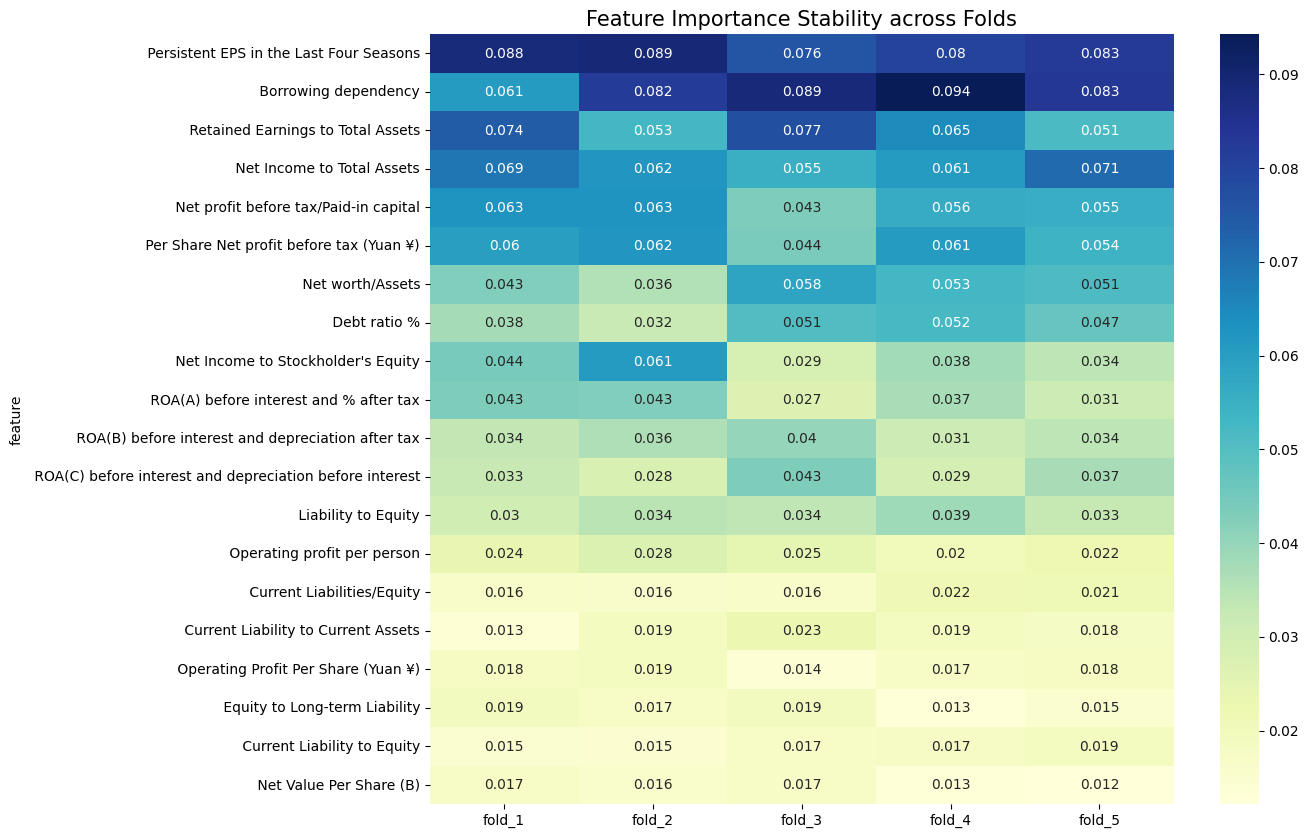

--- 변동성이 심한(불안정한) 피처 TOP 5 ---
                                      average        std
feature                                                 
Borrowing dependency               0.08171403 0.01135366
Net Income to Stockholder's Equity 0.04108327 0.01096772
Retained Earnings to Total Assets  0.06411650 0.01063984
Net worth/Assets                   0.04817209 0.00788779
Debt ratio %                       0.04392622 0.00768045


In [57]:
# Fold별 중요도를 저장할 리스트
fold_importances = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_idx, val_idx) in enumerate(skf.split(X_eng, y)):
    X_tr, X_val = X_eng.iloc[train_idx], X_eng.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # SMOTE (학습 데이터에만)
    smote_fold = SMOTE(sampling_strategy=0.6, random_state=42)
    X_tr_res, y_tr_res = smote_fold.fit_resample(X_tr, y_tr)

    rf_ace.fit(X_tr_res, y_tr_res)

    importance_df = pd.DataFrame({
        'feature': X_eng.columns,
        f'fold_{i+1}': rf_ace.feature_importances_
    })
    fold_importances.append(importance_df.set_index('feature'))

# 모든 폴드 중요도 합치기
df_importance = pd.concat(fold_importances, axis=1)
df_importance['average'] = df_importance.mean(axis=1)
df_importance['std'] = df_importance.std(axis=1) # 중요도의 변동성(표준편차) 계산
df_importance = df_importance.sort_values(by='average', ascending=False)

# 시각화: 상위 20개 피처의 폴드별 변동성
plt.figure(figsize=(12, 10))
top_20_imp = df_importance.head(20)
sns.heatmap(top_20_imp.drop(columns=['average', 'std']), annot=True, cmap='YlGnBu')
plt.title('Feature Importance Stability across Folds', fontsize=15)
plt.show()

# 변동성(std)이 유독 높은 피처 확인
print("--- 변동성이 심한(불안정한) 피처 TOP 5 ---")
print(df_importance.sort_values(by='std', ascending=False)[['average', 'std']].head(5))

In [ ]:
submission_name = f'result.csv'
submission.to_csv(submission_name, index=False)
files.download(submission_name)